# Selected Experiment Metrics Summary

This notebook summarizes the selected CE1 experiment results from `results/` and local `wandb/` folders. The February RBC baseline `rbc_baseline_vt_february` is included.

The CE1 README defines the primary and secondary metrics, but it does not define one official composite score. This notebook therefore shows four views side by side:

1. `overall_rank_score`: an equal-weight average of category rank scores across all major primary and secondary categories.
2. `primary_rank_score`: an equal-weight average of the three primary target categories only.
3. single-objective secondary tables: each secondary objective is ranked on its own, especially for metrics like Fairness that are not ideal to collapse into one recommended score.
4. `recommended_rank_score`: a more defensible custom composite that keeps the three primary categories dominant and only adds a small weight for a few operational secondary metrics.

Recommended composite formula:

`recommended_rank_score = 0.25 * rank(primary_load_cv_rmse_pct) + 0.25 * rank(|primary_load_nmbe_pct|) + 0.25 * average_rank(Thermal Comfort) + 0.10 * rank(site_energy_change) + 0.10 * average_rank(peak_demand metrics) + 0.05 * rank(system_ramping)`

Thermal Comfort is represented by these four values:

- `primary_comfort_exceedance_pct`
- `primary_comfort_exceedance_hours_total`
- `primary_comfort_exceedance_hours_mean`
- `primary_comfort_exceedance_hours_max`

Fairness is kept in the single-objective secondary tables because it is inherently multi-dimensional (`gini`, `entropy`, `max_share_pct`) and is not ideal to force into the recommended composite.


In [73]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

REPO_DIR = Path.cwd()
if not (REPO_DIR / 'results').exists():
    REPO_DIR = REPO_DIR.parent

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

import tools.summarize_selected_experiment_metrics as summary_mod
summary_mod = importlib.reload(summary_mod)

MARKDOWN_COLUMNS = summary_mod.MARKDOWN_COLUMNS
SELECTED_EXPERIMENTS = summary_mod.SELECTED_EXPERIMENTS
SUMMARY_COLUMNS = summary_mod.SUMMARY_COLUMNS
SECONDARY_OBJECTIVE_CATEGORIES = summary_mod.SECONDARY_OBJECTIVE_CATEGORIES
_build_ranked_tables = summary_mod._build_ranked_tables
_build_row = summary_mod._build_row
_write_markdown_table = summary_mod._write_markdown_table
_write_secondary_markdown = summary_mod._write_secondary_markdown

OUTPUT_ROOT = REPO_DIR / 'experiment_metric_summary'
WANDB_ROOT = REPO_DIR / 'wandb'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Repo: {REPO_DIR}')
print(f'Output: {OUTPUT_ROOT}')


Repo: /home/yue/EthanZhu/annex96_common_exercise_1
Output: /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary


## Selected Experiments

In [74]:
pd.DataFrame({'experiment': SELECTED_EXPERIMENTS})

,experiment
0,rbc_baseline_vt_february
1,mappo_standard_vt_500_final
2,mappo_grouped_vt_500_final
3,mappo_grouped_comm_v2_vt_500_final
4,mappo_grouped_tarmac_vt_500_final
5,mappo_grouped_gat_vt_500_final
6,mappo_grouped_powernet_vt_500_final
7,mappo_grouped_powernet_global_vt_500_final
8,mappo_grouped_commnet_vt_500_final
9,mappo_grouped_dial_vt_500_final


## Build Summary Tables

In [75]:
rows = [_build_row(experiment, WANDB_ROOT) for experiment in SELECTED_EXPERIMENTS]
tables = _build_ranked_tables(pd.DataFrame(rows))

ordered_columns = SUMMARY_COLUMNS + [column for column in tables['full'].columns if column not in SUMMARY_COLUMNS]

def order_columns(frame):
    frame_columns = ordered_columns + [column for column in frame.columns if column not in ordered_columns]
    return frame.loc[:, [column for column in frame_columns if column in frame.columns]].copy()

df = order_columns(tables['full'])
overall_df = order_columns(tables['overall'])
primary_only_df = order_columns(tables['primary_only'])
recommended_df = order_columns(tables['recommended'])
secondary_tables = {name: order_columns(frame) for name, frame in tables['secondary'].items()}

full_csv = OUTPUT_ROOT / 'selected_experiment_metrics_full.csv'
report_csv = OUTPUT_ROOT / 'selected_experiment_metrics_report_table.csv'
report_md = OUTPUT_ROOT / 'selected_experiment_metrics_report_table.md'
primary_csv = OUTPUT_ROOT / 'selected_experiment_metrics_primary_only_table.csv'
primary_md = OUTPUT_ROOT / 'selected_experiment_metrics_primary_only_table.md'
recommended_csv = OUTPUT_ROOT / 'selected_experiment_metrics_recommended_table.csv'
recommended_md = OUTPUT_ROOT / 'selected_experiment_metrics_recommended_table.md'
secondary_csv = OUTPUT_ROOT / 'selected_experiment_metrics_secondary_objective_ranks.csv'
secondary_md = OUTPUT_ROOT / 'selected_experiment_metrics_secondary_objective_tables.md'

df.to_csv(full_csv, index=False)
overall_df.to_csv(report_csv, index=False)
primary_only_df.to_csv(primary_csv, index=False)
recommended_df.to_csv(recommended_csv, index=False)
pd.concat([frame.assign(secondary_objective=name) for name, frame in secondary_tables.items()], ignore_index=True).to_csv(secondary_csv, index=False)

_write_markdown_table(report_md, overall_df, MARKDOWN_COLUMNS)
_write_markdown_table(primary_md, primary_only_df, [
    'primary_rank',
    'experiment',
    'primary_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_abs_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'test_reward_sum',
    'wandb_run_id',
])
_write_markdown_table(recommended_md, recommended_df, [
    'recommended_rank',
    'experiment',
    'recommended_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'secondary_site_energy_change_pct',
    'secondary_peak_demand_change_pct',
    'secondary_system_ramping_kw',
    'test_reward_sum',
    'wandb_run_id',
])
_write_secondary_markdown(secondary_md, secondary_tables)

print(f'Full metrics table -> {full_csv}')
print(f'Overall composite table -> {report_csv}')
print(f'Primary-only table -> {primary_csv}')
print(f'Recommended composite table -> {recommended_csv}')
print(f'Secondary single-objective tables -> {secondary_csv}')


Full metrics table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_full.csv
Overall composite table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_report_table.csv
Primary-only table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_primary_only_table.csv
Recommended composite table -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_recommended_table.csv
Secondary single-objective tables -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_metrics_secondary_objective_ranks.csv


## Overall Composite Report Table

In [76]:
overall_columns = [column for column in MARKDOWN_COLUMNS if column in overall_df.columns]
overall_view = overall_df[overall_columns].set_index('overall_rank')
display(overall_view)


,overall_rank_score,primary_rank,experiment,primary_rank_score,recommended_rank,recommended_rank_score,primary_load_cv_rmse_pct,primary_load_nmbe_pct,primary_comfort_exceedance_pct,primary_comfort_exceedance_hours_total,...,secondary_peak_to_valley_ratio_pct,secondary_peak_to_valley_ratio_baseline_pct,secondary_load_factor_pct,secondary_load_factor_baseline_pct,secondary_system_ramping_kw,secondary_system_ramping_baseline_kw,secondary_fairness_gini,secondary_fairness_entropy,secondary_fairness_max_share_pct,wandb_run_id
overall_rank,,,,,,,,,,,,,,,,,,,,,
1,5.0463,3,sb3_independent_sac_vt_50_final,4.9167,1,4.3375,51.8727,-18.7886,48.4762,8144.0,...,4838.4066,213.5126,58.6162,72.2941,375.8008,200.5224,0.1794,0.9841,6.8763,kru9ntwg
2,5.7500,1,mappo_grouped_comm_v2_vt_500_final,2.0833,2,4.3625,49.9360,-17.7413,47.5060,7981.0,...,701.3766,213.7573,57.5672,72.1070,438.8111,202.9093,0.1796,0.9844,6.9108,hmdcbj2c
6,6.9722,2,mappo_grouped_tarmac_vt_500_final,4.4167,3,5.5625,50.9250,-18.5564,48.8869,8213.0,...,4117.5192,214.1579,56.5748,72.1774,457.2130,201.9695,0.1564,0.9880,6.9350,g6o68ph0
3,6.1296,6,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,6.3333,4,6.5000,52.2456,-18.9314,50.3036,8451.0,...,705.3816,214.4248,55.8225,72.1785,430.1385,202.1119,0.1784,0.9847,6.3584,d2ufgjyr
13,8.9444,5,mappo_grouped_comm_weighted_default_vt_500_final,5.8333,5,6.8250,55.0538,-18.0635,48.4940,8147.0,...,2418.9518,217.8852,53.6229,71.8089,460.6572,206.2144,0.1906,0.9821,6.8049,49wv21gn
9,8.4722,4,mappo_grouped_gat_vt_500_final,4.9167,6,7.1375,56.1046,-16.6212,46.9167,7882.0,...,1367.0630,214.3891,54.8043,71.9627,515.1382,202.9743,0.1276,0.9910,6.6795,63msj7dg
5,6.8056,11,rllib_independent_ppo_vt_42_final,9.2500,7,7.2875,51.7825,-21.8354,63.2560,10627.0,...,1557.3874,212.2553,56.5247,72.4826,380.3387,198.8471,0.2841,0.9574,11.4578,8v55jxl2
8,8.0648,7,mappo_grouped_powernet_vt_500_final,6.9167,8,7.2875,55.4132,-19.1565,48.2143,8100.0,...,2126.5163,214.9592,55.3263,71.9762,484.7071,202.9297,0.1784,0.9847,6.6989,v9rnhpdr
4,6.2778,8,mappo_grouped_comm_weighted_a055_b045_vt_500_f...,8.3333,9,8.2000,52.5812,-19.6803,50.9583,8561.0,...,565.6257,213.8392,57.5672,72.0967,439.3900,207.0577,0.1527,0.9881,7.6350,47ney6ne


## Primary-Only Ranking

In [77]:
primary_columns = [
    'primary_rank',
    'experiment',
    'primary_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_abs_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'test_reward_sum',
    'wandb_run_id',
]
primary_view = primary_only_df[[column for column in primary_columns if column in primary_only_df.columns]].set_index('primary_rank')
display(primary_view)


,experiment,primary_rank_score,primary_load_cv_rmse_pct,primary_load_nmbe_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,primary_comfort_exceedance_hours_total,primary_comfort_exceedance_hours_mean,primary_comfort_exceedance_hours_max,test_reward_sum,wandb_run_id
primary_rank,,,,,,,,,,,
1,mappo_grouped_comm_v2_vt_500_final,2.0833,49.9360,-17.7413,17.7413,47.5060,7981.0,319.24,671.0,-22907.8639,hmdcbj2c
2,mappo_grouped_tarmac_vt_500_final,4.4167,50.9250,-18.5564,18.5564,48.8869,8213.0,328.52,672.0,-24165.2505,g6o68ph0
3,sb3_independent_sac_vt_50_final,4.9167,51.8727,-18.7886,18.7886,48.4762,8144.0,325.76,672.0,-15769.3593,kru9ntwg
4,mappo_grouped_gat_vt_500_final,4.9167,56.1046,-16.6212,16.6212,46.9167,7882.0,315.28,672.0,-21774.5339,63msj7dg
5,mappo_grouped_comm_weighted_default_vt_500_final,5.8333,55.0538,-18.0635,18.0635,48.4940,8147.0,325.88,669.0,-38047.5110,49wv21gn
6,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,6.3333,52.2456,-18.9314,18.9314,50.3036,8451.0,338.04,672.0,-26034.5090,d2ufgjyr
7,mappo_grouped_powernet_vt_500_final,6.9167,55.4132,-19.1565,19.1565,48.2143,8100.0,324.00,670.0,-27805.0000,v9rnhpdr
8,mappo_grouped_comm_weighted_a055_b045_vt_500_f...,8.3333,52.5812,-19.6803,19.6803,50.9583,8561.0,342.44,661.0,-42622.6204,47ney6ne
9,mappo_standard_vt_500_final,8.7500,52.4720,-19.9395,19.9395,52.4345,8809.0,352.36,672.0,-13104.3853,2ownbj08


## Secondary Single-Objective Tables

In [78]:
secondary_display_columns = {
    'fairness': [
        'experiment',
        'fairness_rank_score',
        'secondary_fairness_gini',
        'secondary_fairness_entropy',
        'secondary_fairness_max_share_pct',
    ],
    'site_energy': [
        'experiment',
        'site_energy_rank_score',
        'secondary_site_energy_change_pct',
        'secondary_site_total_energy_kwh',
        'secondary_site_total_energy_baseline_kwh',
    ],
    'peak_demand': [
        'experiment',
        'peak_demand_rank_score',
        'secondary_peak_demand_kw',
        'secondary_peak_demand_baseline_kw',
        'secondary_peak_demand_change_pct',
        'secondary_peak_demand_time',
        'secondary_peak_demand_baseline_time',
    ],
    'peak_to_valley_ratio': [
        'experiment',
        'peak_to_valley_ratio_rank_score',
        'secondary_peak_to_valley_ratio_pct',
        'secondary_peak_to_valley_ratio_baseline_pct',
    ],
    'load_factor': [
        'experiment',
        'load_factor_rank_score',
        'secondary_load_factor_pct',
        'secondary_load_factor_baseline_pct',
    ],
    'system_ramping': [
        'experiment',
        'system_ramping_rank_score',
        'secondary_system_ramping_kw',
        'secondary_system_ramping_baseline_kw',
    ],
}

for category in SECONDARY_OBJECTIVE_CATEGORIES:
    table = secondary_tables[category]
    rank_column = f'{category}_rank'
    display(Markdown(f"### {category.replace('_', ' ').title()}"))
    view_columns = [rank_column] + [column for column in secondary_display_columns[category] if column in table.columns]
    display(table[view_columns].set_index(rank_column))


### Fairness

,experiment,fairness_rank_score,secondary_fairness_gini,secondary_fairness_entropy,secondary_fairness_max_share_pct
fairness_rank,,,,,
1,mappo_grouped_dial_vt_500_final,1.6667,0.1450,0.9899,5.6621
2,mappo_grouped_gat_vt_500_final,2.0000,0.1276,0.9910,6.6795
3,mappo_grouped_powernet_global_vt_500_final,4.6667,0.1612,0.9869,5.9725
4,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,5.6667,0.1784,0.9847,6.3584
5,mappo_grouped_comm_weighted_a055_b045_vt_500_f...,6.0000,0.1527,0.9881,7.6350
6,mappo_grouped_tarmac_vt_500_final,6.0000,0.1564,0.9880,6.9350
7,mappo_grouped_powernet_vt_500_final,6.3333,0.1784,0.9847,6.6989
8,mappo_grouped_vt_500_final,6.3333,0.1558,0.9875,7.3038
9,sb3_independent_sac_vt_50_final,8.6667,0.1794,0.9841,6.8763


### Site Energy

,experiment,site_energy_rank_score,secondary_site_energy_change_pct,secondary_site_total_energy_kwh,secondary_site_total_energy_baseline_kwh
site_energy_rank,,,,,
1,rllib_independent_ppo_vt_42_final,1.0,3.6674,52481.1949,67141.9241
2,mappo_grouped_dial_vt_500_final,2.0,4.8311,46747.7355,65930.3420
3,sb3_independent_sac_vt_50_final,3.0,6.1763,54865.0038,67558.2211
4,mappo_standard_vt_500_final,4.0,6.4546,53559.1055,66898.2506
5,mappo_grouped_commnet_vt_500_final,5.0,6.4590,52926.1488,67014.4691
6,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,6.0,8.3178,54391.3361,67092.9727
7,mappo_grouped_powernet_global_vt_500_final,7.0,9.1855,54040.3985,67210.1409
8,mappo_grouped_vt_500_final,8.0,9.4842,53558.5780,67126.4778
9,mappo_grouped_tarmac_vt_500_final,9.0,9.8317,54928.1139,67443.1444


### Peak Demand

...

,experiment,peak_to_valley_ratio_rank_score,secondary_peak_to_valley_ratio_pct,secondary_peak_to_valley_ratio_baseline_pct
peak_to_valley_ratio_rank,,,,
1,mappo_grouped_comm_weighted_a055_b045_vt_500_f...,1.0,565.6257,213.8392
2,mappo_grouped_powernet_global_vt_500_final,2.0,695.6999,213.7030
3,mappo_standard_vt_500_final,3.0,698.0796,215.4816
4,mappo_grouped_comm_v2_vt_500_final,4.0,701.3766,213.7573
5,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,5.0,705.3816,214.4248
6,mappo_grouped_dial_vt_500_final,6.0,708.6260,218.1291
7,mappo_grouped_vt_500_final,7.0,852.3265,215.3854
8,mappo_grouped_commnet_vt_500_final,8.0,1098.6709,213.2035
9,mappo_grouped_gat_vt_500_final,9.0,1367.0630,214.3891


### Load Factor

,experiment,load_factor_rank_score,secondary_load_factor_pct,secondary_load_factor_baseline_pct
load_factor_rank,,,,
1,sb3_independent_sac_vt_50_final,1.0,58.6162,72.2941
2,mappo_grouped_comm_v2_vt_500_final,2.0,57.5672,72.1070
3,mappo_grouped_comm_weighted_a055_b045_vt_500_f...,2.0,57.5672,72.0967
4,mappo_grouped_tarmac_vt_500_final,4.0,56.5748,72.1774
5,rllib_independent_ppo_vt_42_final,5.0,56.5247,72.4826
6,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,6.0,55.8225,72.1785
7,mappo_grouped_commnet_vt_500_final,7.0,55.3975,72.1800
8,mappo_grouped_powernet_vt_500_final,8.0,55.3263,71.9762
9,mappo_standard_vt_500_final,9.0,55.2132,71.9739


### System Ramping

,experiment,system_ramping_rank_score,secondary_system_ramping_kw,secondary_system_ramping_baseline_kw
system_ramping_rank,,,,
1,sb3_independent_sac_vt_50_final,1.0,375.8008,200.5224
2,rllib_independent_ppo_vt_42_final,2.0,380.3387,198.8471
3,mappo_standard_vt_500_final,3.0,418.5334,203.6788
4,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,4.0,430.1385,202.1119
5,mappo_grouped_comm_v2_vt_500_final,5.0,438.8111,202.9093
6,mappo_grouped_comm_weighted_a055_b045_vt_500_f...,6.0,439.3900,207.0577
7,mappo_grouped_commnet_vt_500_final,7.0,440.5392,203.0690
8,mappo_grouped_tarmac_vt_500_final,8.0,457.2130,201.9695
9,mappo_grouped_comm_weighted_default_vt_500_final,9.0,460.6572,206.2144


## Recommended Composite Ranking

In [79]:
recommended_columns = [
    'recommended_rank',
    'experiment',
    'recommended_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'secondary_site_energy_change_pct',
    'secondary_peak_demand_change_pct',
    'secondary_system_ramping_kw',
    'test_reward_sum',
    'wandb_run_id',
]
recommended_view = recommended_df[[column for column in recommended_columns if column in recommended_df.columns]].set_index('recommended_rank')
display(recommended_view)


,experiment,recommended_rank_score,primary_load_cv_rmse_pct,primary_load_nmbe_pct,primary_comfort_exceedance_pct,primary_comfort_exceedance_hours_total,primary_comfort_exceedance_hours_mean,primary_comfort_exceedance_hours_max,secondary_site_energy_change_pct,secondary_peak_demand_change_pct,secondary_system_ramping_kw,test_reward_sum,wandb_run_id
recommended_rank,,,,,,,,,,,,,
1,sb3_independent_sac_vt_50_final,4.3375,51.8727,-18.7886,48.4762,8144.0,325.76,672.0,6.1763,-10.9652,375.8008,-15769.3593,kru9ntwg
2,mappo_grouped_comm_v2_vt_500_final,4.3625,49.9360,-17.7413,47.5060,7981.0,319.24,671.0,10.2055,-2.1036,438.8111,-22907.8639,hmdcbj2c
3,mappo_grouped_tarmac_vt_500_final,5.5625,50.9250,-18.5564,48.8869,8213.0,328.52,672.0,9.8317,-4.4682,457.2130,-24165.2505,g6o68ph0
4,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,6.5000,52.2456,-18.9314,50.3036,8451.0,338.04,672.0,8.3178,-5.1421,430.1385,-26034.5090,d2ufgjyr
5,mappo_grouped_comm_weighted_default_vt_500_final,6.8250,55.0538,-18.0635,48.4940,8147.0,325.88,669.0,10.9651,-7.7428,460.6572,-38047.5110,49wv21gn
6,mappo_grouped_gat_vt_500_final,7.1375,56.1046,-16.6212,46.9167,7882.0,315.28,672.0,13.8176,-2.7197,515.1382,-21774.5339,63msj7dg
7,rllib_independent_ppo_vt_42_final,7.2875,51.7825,-21.8354,63.2560,10627.0,425.08,672.0,3.6674,-11.4869,380.3387,-79395.8399,8v55jxl2
8,mappo_grouped_powernet_vt_500_final,7.2875,55.4132,-19.1565,48.2143,8100.0,324.00,670.0,9.8928,-8.8996,484.7071,-27805.0000,v9rnhpdr
9,mappo_grouped_comm_weighted_a055_b045_vt_500_f...,8.2000,52.5812,-19.6803,50.9583,8561.0,342.44,661.0,10.2272,-9.7877,439.3900,-42622.6204,47ney6ne


## Primary Metrics Plots

Plot -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_primary_metrics.png


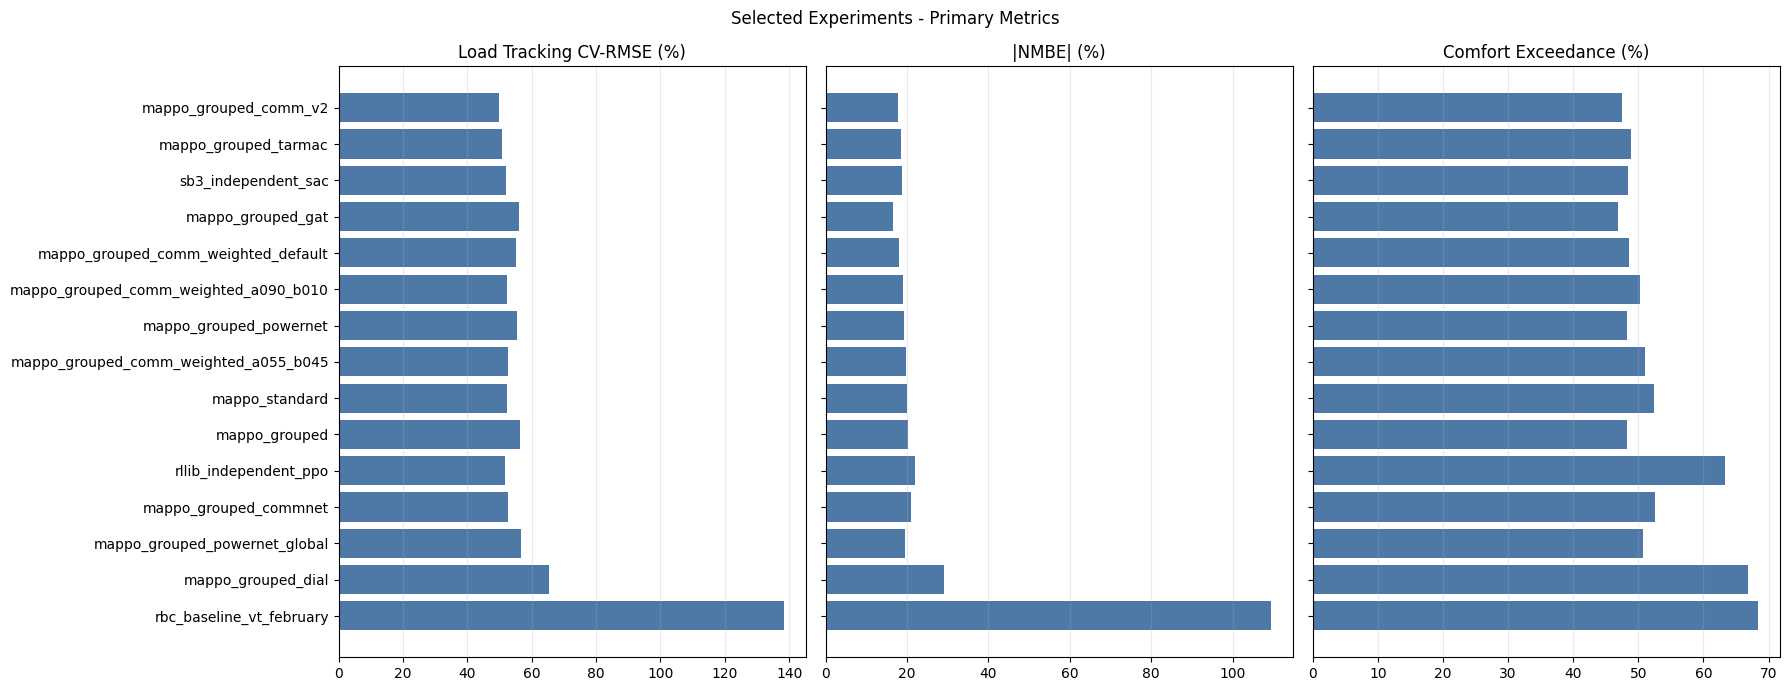

In [80]:
plot_df = primary_only_df.sort_values('primary_rank').copy()
labels = plot_df['experiment'].str.replace('_vt_500_final', '', regex=False)
labels = labels.str.replace('_vt_42_final', '', regex=False)
labels = labels.str.replace('_vt_50_final', '', regex=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

metrics = [
    ('primary_load_cv_rmse_pct', 'Load Tracking CV-RMSE (%)'),
    ('primary_abs_nmbe_pct', '|NMBE| (%)'),
    ('primary_comfort_exceedance_pct', 'Comfort Exceedance (%)'),
]

for ax, (column, title) in zip(axes, metrics):
    ax.barh(labels, plot_df[column], color='#4e79a7')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

fig.suptitle('Selected Experiments - Primary Metrics')
fig.tight_layout()

plot_path = OUTPUT_ROOT / 'selected_experiment_primary_metrics.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print(f'Plot -> {plot_path}')
plt.show()


## Secondary Metrics Plots

Plot -> /home/yue/EthanZhu/annex96_common_exercise_1/experiment_metric_summary/selected_experiment_secondary_metrics.png


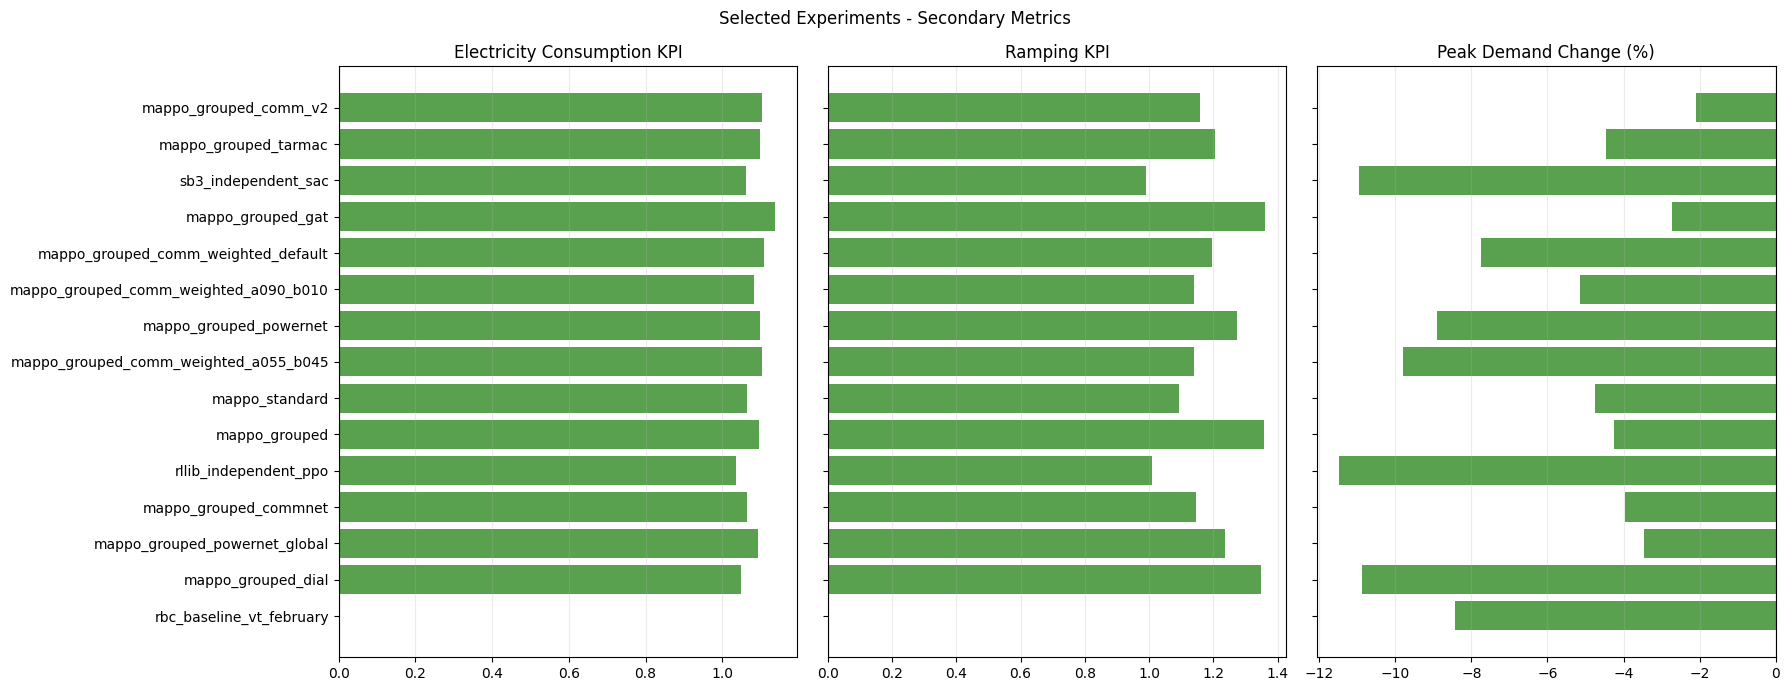

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

secondary_metrics = [
    ('kpi_electricity_consumption', 'Electricity Consumption KPI'),
    ('kpi_ramping', 'Ramping KPI'),
    ('secondary_peak_demand_change_pct', 'Peak Demand Change (%)'),
]

for ax, (column, title) in zip(axes, secondary_metrics):
    ax.barh(labels, plot_df[column], color='#59a14f')
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

fig.suptitle('Selected Experiments - Secondary Metrics')
fig.tight_layout()

plot_path = OUTPUT_ROOT / 'selected_experiment_secondary_metrics.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print(f'Plot -> {plot_path}')
plt.show()


## W&B Match Check

In [82]:
wandb_check_columns = ['experiment', 'wandb_run_id', 'wandb_started_at', 'wandb_program', 'wandb_run_dir']
display(df[[column for column in wandb_check_columns if column in df.columns]])


,experiment,wandb_run_id,wandb_started_at,wandb_program,wandb_run_dir
0,sb3_independent_sac_vt_50_final,kru9ntwg,2026-04-23T04:33:19.608286Z,-m sb3_independent_sac.train,wandb/run-20260423_123319-kru9ntwg
1,mappo_grouped_comm_v2_vt_500_final,hmdcbj2c,2026-04-21T04:22:48.051394Z,-m mappo_grouped_comm_v2.train,wandb/run-20260421_142248-hmdcbj2c
2,mappo_grouped_tarmac_vt_500_final,g6o68ph0,2026-04-21T21:18:45.699930Z,-m mappo_grouped_tarmac.train,wandb/run-20260422_071845-g6o68ph0
3,mappo_grouped_comm_weighted_a090_b010_vt_500_f...,d2ufgjyr,2026-04-22T14:31:41.199612Z,-m mappo_grouped_comm_weighted.train,wandb/run-20260422_223141-d2ufgjyr
4,mappo_grouped_comm_weighted_default_vt_500_final,49wv21gn,2026-04-22T14:31:41.825582Z,-m mappo_grouped_comm_weighted.train,wandb/run-20260422_223141-49wv21gn
5,mappo_grouped_gat_vt_500_final,63msj7dg,2026-04-22T14:31:41.277248Z,-m mappo_grouped_gat.train,wandb/run-20260422_223141-63msj7dg
6,rllib_independent_ppo_vt_42_final,8v55jxl2,2026-04-23T04:29:05.018778Z,-m rllib_independent_ppo.train,wandb/run-20260423_122905-8v55jxl2
7,mappo_grouped_powernet_vt_500_final,v9rnhpdr,2026-04-22T14:31:41.157032Z,-m mappo_grouped_powernet.train,wandb/run-20260422_223141-v9rnhpdr
8,mappo_grouped_comm_weighted_a055_b045_vt_500_f...,47ney6ne,2026-04-22T14:31:41.329708Z,-m mappo_grouped_comm_weighted.train,wandb/run-20260422_223141-47ney6ne
9,mappo_standard_vt_500_final,2ownbj08,2026-04-20T15:44:45.365025Z,-m mappo_standard.train,wandb/run-20260421_014445-2ownbj08
